In [350]:
#Smart EV Charging Station Recommendation System using Machine Learning-Based Wait Time Prediction
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib as plt

In [351]:
data = pd.read_csv('/content/EV_Charging_80_20_Balanced.csv')
data.head()

,timestamp,station_id,station_name,network,city,state,latitude,longitude,location_type,charger_type,...,precipitation_mm,weather_condition,gas_price_per_gallon,traffic_congestion_index,local_event,is_weekend,is_peak_hour,hour_of_day,day_of_week,month
0,2025-10-18 04:30:00,EV00011,Shell Recharge - Phoenix #11,Shell Recharge,Phoenix,AZ,33.329302,-112.014730,Workplace,DC Fast Charge,...,0.0,clear,3.37,3,none,True,False,4,5,10
1,2025-10-11 04:30:00,EV00002,Electrify America - Seattle #2,Electrify America,Seattle,WA,47.506806,-122.433202,Residential,DC Fast Charge,...,0.0,cloudy,4.37,1,none,True,False,4,5,10
2,2025-09-07 19:30:00,EV00023,Tesla Supercharger - Chicago #3,Tesla Supercharger,Chicago,IL,41.823295,-87.682445,Urban Center,Tesla DC Fast,...,0.0,clear,3.49,10,none,True,True,19,6,9
3,2025-11-15 16:00:00,EV00005,Blink - Phoenix #5,Blink,Phoenix,AZ,33.391273,-112.062573,Workplace,DC Fast Charge,...,0.0,clear,3.63,7,concert,True,False,16,5,11
4,2025-08-12 18:30:00,EV00128,ChargePoint - New York #8,ChargePoint,New York,NY,40.845123,-73.892921,Suburban,Level 2,...,0.0,partly_cloudy,4.23,7,none,False,True,18,1,8


In [352]:
data.columns

Index(['timestamp', 'station_id', 'station_name', 'network', 'city', 'state',
       'latitude', 'longitude', 'location_type', 'charger_type',
       'power_output_kw', 'amenities_nearby', 'ports_total', 'ports_available',
       'ports_occupied', 'ports_out_of_service', 'utilization_rate',
       'station_status', 'estimated_wait_time_mins',
       'avg_session_duration_mins', 'current_price', 'pricing_type',
       'temperature_f', 'precipitation_mm', 'weather_condition',
       'gas_price_per_gallon', 'traffic_congestion_index', 'local_event',
       'is_weekend', 'is_peak_hour', 'hour_of_day', 'day_of_week', 'month'],
      dtype='object')

In [353]:
data.shape

(105477, 33)

In [354]:
data.dtypes

,0
timestamp,object
station_id,object
station_name,object
network,object
city,object
state,object
latitude,float64
longitude,float64
location_type,object
charger_type,object


In [355]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105477 entries, 0 to 105476
Data columns (total 33 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   timestamp                  105477 non-null  object 
 1   station_id                 105477 non-null  object 
 2   station_name               105477 non-null  object 
 3   network                    105477 non-null  object 
 4   city                       105477 non-null  object 
 5   state                      105477 non-null  object 
 6   latitude                   105477 non-null  float64
 7   longitude                  105477 non-null  float64
 8   location_type              105477 non-null  object 
 9   charger_type               105477 non-null  object 
 10  power_output_kw            105477 non-null  float64
 11  amenities_nearby           105477 non-null  object 
 12  ports_total                105477 non-null  int64  
 13  ports_available            10

In [356]:
data.describe()

,latitude,longitude,power_output_kw,ports_total,ports_available,ports_occupied,ports_out_of_service,utilization_rate,estimated_wait_time_mins,avg_session_duration_mins,current_price,temperature_f,precipitation_mm,gas_price_per_gallon,traffic_congestion_index,hour_of_day,day_of_week,month
count,105477.000000,105477.000000,105477.000000,105477.000000,105477.000000,105477.000000,105477.000000,105477.000000,105477.000000,105477.000000,105477.000000,105477.000000,105477.000000,105477.000000,105477.000000,105477.000000,105477.000000,105477.000000
mean,37.671765,-101.090346,133.463622,6.722205,0.902965,0.509675,5.309565,0.412463,32.152422,81.200100,0.320186,71.219651,0.579517,3.951495,4.992596,11.495938,2.994236,9.479128
std,5.767950,17.854970,127.315473,4.300236,2.349969,1.807288,4.587439,0.301868,36.871200,71.949912,0.158078,21.064067,2.321934,0.598601,2.483877,6.920007,1.999484,1.706523
min,25.619429,-122.812732,7.200000,2.000000,0.000000,0.000000,0.000000,0.020000,0.000000,21.000000,0.000000,20.100000,0.000000,3.280000,1.000000,0.000000,0.000000,7.000000
25%,33.498059,-117.276641,19.200000,4.000000,0.000000,0.000000,2.000000,0.119000,10.000000,31.000000,0.250000,59.200000,0.000000,3.480000,3.000000,5.000000,1.000000,8.000000
50%,37.774197,-104.938490,100.000000,6.000000,0.000000,0.000000,4.000000,0.393000,18.000000,41.000000,0.345000,74.400000,0.000000,3.680000,5.000000,11.000000,3.000000,9.000000
75%,41.977937,-84.511898,250.000000,8.000000,0.000000,0.000000,8.000000,0.649000,47.000000,140.000000,0.425000,87.000000,0.000000,4.370000,7.000000,18.000000,5.000000,11.000000
max,47.727768,-70.912984,350.000000,24.000000,24.000000,23.000000,24.000000,0.980000,134.000000,251.000000,0.696000,109.900000,48.400000,5.500000,10.000000,23.000000,6.000000,12.000000


In [357]:
data.isnull().sum()

,0
timestamp,0
station_id,0
station_name,0
network,0
city,0
state,0
latitude,0
longitude,0
location_type,0
charger_type,0


In [358]:
display(data.tail())

,timestamp,station_id,station_name,network,city,state,latitude,longitude,location_type,charger_type,...,precipitation_mm,weather_condition,gas_price_per_gallon,traffic_congestion_index,local_event,is_weekend,is_peak_hour,hour_of_day,day_of_week,month
105472,2025-08-25 10:00:00,EV00094,Tesla Supercharger - Seattle #14,Tesla Supercharger,Seattle,WA,47.467953,-122.304267,Highway Corridor,Tesla DC Fast,...,0.0,partly_cloudy,4.12,3,none,False,False,10,0,8
105473,2025-08-27 01:00:00,EV00136,Electrify America - Miami #16,Electrify America,Miami,FL,25.655125,-80.161761,Highway Corridor,Hyper-Fast,...,0.0,extreme_heat,3.59,3,none,False,False,1,2,8
105474,2025-07-03 09:30:00,EV00143,Blink - Los Angeles #3,Blink,Los Angeles,CA,33.934067,-118.198528,Urban Center,DC Fast Charge,...,12.1,heavy_rain,4.75,8,none,False,True,9,3,7
105475,2025-10-11 21:00:00,EV00002,Electrify America - Seattle #2,Electrify America,Seattle,WA,47.506806,-122.433202,Residential,DC Fast Charge,...,0.0,clear,4.32,5,none,True,False,21,5,10
105476,2025-09-15 00:00:00,EV00027,Volta - Miami #7,Volta,Miami,FL,25.619429,-80.149077,Suburban,Level 2,...,0.0,partly_cloudy,3.54,1,none,False,False,0,0,9


In [359]:
data['network'].value_counts()

,count
network,
Electrify America,17100
Blink,15725
Shell Recharge,15248
Volta,14510
Tesla Supercharger,12861
EVCS,12171
ChargePoint,11627
EVgo,6235


In [360]:
data.dtypes


,0
timestamp,object
station_id,object
station_name,object
network,object
city,object
state,object
latitude,float64
longitude,float64
location_type,object
charger_type,object


In [361]:
columns_to_drop = ['station_name', 'timestamp', 'latitude', 'longitude']
data.drop(columns=columns_to_drop, inplace=True)

In [362]:
data.shape

(105477, 29)

In [363]:
data.columns

Index(['station_id', 'network', 'city', 'state', 'location_type',
       'charger_type', 'power_output_kw', 'amenities_nearby', 'ports_total',
       'ports_available', 'ports_occupied', 'ports_out_of_service',
       'utilization_rate', 'station_status', 'estimated_wait_time_mins',
       'avg_session_duration_mins', 'current_price', 'pricing_type',
       'temperature_f', 'precipitation_mm', 'weather_condition',
       'gas_price_per_gallon', 'traffic_congestion_index', 'local_event',
       'is_weekend', 'is_peak_hour', 'hour_of_day', 'day_of_week', 'month'],
      dtype='object')

In [364]:
data["charger_type"].value_counts()

,count
charger_type,
DC Fast Charge,50266
Level 2,34055
Tesla DC Fast,12861
Hyper-Fast,8295


### Encoding

In [365]:
data.dtypes

,0
station_id,object
network,object
city,object
state,object
location_type,object
charger_type,object
power_output_kw,float64
amenities_nearby,object
ports_total,int64
ports_available,int64


In [366]:
len(data)

105477

In [367]:
print(f"'station id': {data['station_id'].nunique()} ")
print(f"'network': {data['network'].nunique()} ")
print(f"'city': {data['city'].nunique()} ")
print(f"'state': {data['state'].nunique()} ")
print(f"'location_type': {data['location_type'].nunique()} ")
print(f"'charger_type': {data['charger_type'].nunique()} ")
print(f"'amenities_nearby': {data['amenities_nearby'].nunique()} ")
print(f"'station_status': {data['station_status'].nunique()} ")
print(f"'pricing_type': {data['pricing_type'].nunique()} ")
print(f"'weather_condition': {data['weather_condition'].nunique()} ")
print(f"'local_event': {data['local_event'].nunique()} ")

'station id': 150 
'network': 8 
'city': 15 
'state': 13 
'location_type': 8 
'charger_type': 4 
'amenities_nearby': 123 
'station_status': 4 
'pricing_type': 3 
'weather_condition': 7 
'local_event': 5 


In [368]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [369]:
station_id_counts = data['station_id'].value_counts()
data['station_id_freq_encoded'] = data['station_id'].map(station_id_counts)
data.drop(columns=['station_id'], inplace=True)
display(data.head())

,network,city,state,location_type,charger_type,power_output_kw,amenities_nearby,ports_total,ports_available,ports_occupied,...,weather_condition,gas_price_per_gallon,traffic_congestion_index,local_event,is_weekend,is_peak_hour,hour_of_day,day_of_week,month,station_id_freq_encoded
0,Shell Recharge,Phoenix,AZ,Workplace,DC Fast Charge,50.0,"Restaurant, Restroom",6,0,0,...,clear,3.37,3,none,True,False,4,5,10,660
1,Electrify America,Seattle,WA,Residential,DC Fast Charge,150.0,"Park, WiFi, Restaurant, Fast Food",4,4,0,...,cloudy,4.37,1,none,True,False,4,5,10,656
2,Tesla Supercharger,Chicago,IL,Urban Center,Tesla DC Fast,350.0,"Shopping Mall, Park, Coffee Shop",4,0,0,...,clear,3.49,10,none,True,True,19,6,9,778
3,Blink,Phoenix,AZ,Workplace,DC Fast Charge,7.2,"WiFi, Shopping Mall",6,0,0,...,clear,3.63,7,concert,True,False,16,5,11,710
4,ChargePoint,New York,NY,Suburban,Level 2,19.2,"Restaurant, Park, Shopping Mall, Hotel, Conven...",6,1,1,...,partly_cloudy,4.23,7,none,False,True,18,1,8,533


In [370]:
amenities_nearby_counts = data['amenities_nearby'].value_counts()
data['amenities_nearby_freq_encoded'] = data['amenities_nearby'].map(amenities_nearby_counts)
data.drop(columns=['amenities_nearby'], inplace=True)
display(data.head())

,network,city,state,location_type,charger_type,power_output_kw,ports_total,ports_available,ports_occupied,ports_out_of_service,...,gas_price_per_gallon,traffic_congestion_index,local_event,is_weekend,is_peak_hour,hour_of_day,day_of_week,month,station_id_freq_encoded,amenities_nearby_freq_encoded
0,Shell Recharge,Phoenix,AZ,Workplace,DC Fast Charge,50.0,6,0,0,6,...,3.37,3,none,True,False,4,5,10,660,660
1,Electrify America,Seattle,WA,Residential,DC Fast Charge,150.0,4,4,0,0,...,4.37,1,none,True,False,4,5,10,656,656
2,Tesla Supercharger,Chicago,IL,Urban Center,Tesla DC Fast,350.0,4,0,0,4,...,3.49,10,none,True,True,19,6,9,778,778
3,Blink,Phoenix,AZ,Workplace,DC Fast Charge,7.2,6,0,0,6,...,3.63,7,concert,True,False,16,5,11,710,2260
4,ChargePoint,New York,NY,Suburban,Level 2,19.2,6,1,1,4,...,4.23,7,none,False,True,18,1,8,533,533


In [371]:
#One hot encode
data = pd.get_dummies(data, columns=['network'], dtype=int)
data.head()

,city,state,location_type,charger_type,power_output_kw,ports_total,ports_available,ports_occupied,ports_out_of_service,utilization_rate,...,station_id_freq_encoded,amenities_nearby_freq_encoded,network_Blink,network_ChargePoint,network_EVCS,network_EVgo,network_Electrify America,network_Shell Recharge,network_Tesla Supercharger,network_Volta
0,Phoenix,AZ,Workplace,DC Fast Charge,50.0,6,0,0,6,0.020,...,660,660,0,0,0,0,0,1,0,0
1,Seattle,WA,Residential,DC Fast Charge,150.0,4,4,0,0,0.187,...,656,656,0,0,0,0,1,0,0,0
2,Chicago,IL,Urban Center,Tesla DC Fast,350.0,4,0,0,4,0.638,...,778,778,0,0,0,0,0,0,1,0
3,Phoenix,AZ,Workplace,DC Fast Charge,7.2,6,0,0,6,0.070,...,710,2260,1,0,0,0,0,0,0,0
4,New York,NY,Suburban,Level 2,19.2,6,1,1,4,0.528,...,533,533,0,1,0,0,0,0,0,0


In [372]:
data = pd.get_dummies(data, columns=['city'], dtype=int)
display(data.head())

,state,location_type,charger_type,power_output_kw,ports_total,ports_available,ports_occupied,ports_out_of_service,utilization_rate,station_status,...,city_Las Vegas,city_Los Angeles,city_Miami,city_Minneapolis,city_New York,city_Phoenix,city_Portland,city_San Diego,city_San Francisco,city_Seattle
0,AZ,Workplace,DC Fast Charge,50.0,6,0,0,6,0.020,offline,...,0,0,0,0,0,1,0,0,0,0
1,WA,Residential,DC Fast Charge,150.0,4,4,0,0,0.187,operational,...,0,0,0,0,0,0,0,0,0,1
2,IL,Urban Center,Tesla DC Fast,350.0,4,0,0,4,0.638,offline,...,0,0,0,0,0,0,0,0,0,0
3,AZ,Workplace,DC Fast Charge,7.2,6,0,0,6,0.070,under_maintenance,...,0,0,0,0,0,1,0,0,0,0
4,NY,Suburban,Level 2,19.2,6,1,1,4,0.528,partial_outage,...,0,0,0,0,1,0,0,0,0,0


In [373]:
data = pd.get_dummies(data, columns=['state'], dtype=int)
display(data.head())

,location_type,charger_type,power_output_kw,ports_total,ports_available,ports_occupied,ports_out_of_service,utilization_rate,station_status,estimated_wait_time_mins,...,state_FL,state_GA,state_IL,state_MA,state_MN,state_NV,state_NY,state_OR,state_TX,state_WA
0,Workplace,DC Fast Charge,50.0,6,0,0,6,0.020,offline,17,...,0,0,0,0,0,0,0,0,0,0
1,Residential,DC Fast Charge,150.0,4,4,0,0,0.187,operational,0,...,0,0,0,0,0,0,0,0,0,1
2,Urban Center,Tesla DC Fast,350.0,4,0,0,4,0.638,offline,24,...,0,0,1,0,0,0,0,0,0,0
3,Workplace,DC Fast Charge,7.2,6,0,0,6,0.070,under_maintenance,11,...,0,0,0,0,0,0,0,0,0,0
4,Suburban,Level 2,19.2,6,1,1,4,0.528,partial_outage,0,...,0,0,0,0,0,0,1,0,0,0


In [374]:
data = pd.get_dummies(data, columns=['location_type'], dtype=int)
display(data.head())

,charger_type,power_output_kw,ports_total,ports_available,ports_occupied,ports_out_of_service,utilization_rate,station_status,estimated_wait_time_mins,avg_session_duration_mins,...,state_TX,state_WA,location_type_Airport,location_type_Highway Corridor,location_type_Hotel/Hospitality,location_type_Residential,location_type_Shopping Center,location_type_Suburban,location_type_Urban Center,location_type_Workplace
0,DC Fast Charge,50.0,6,0,0,6,0.020,offline,17,24,...,0,0,0,0,0,0,0,0,0,1
1,DC Fast Charge,150.0,4,4,0,0,0.187,operational,0,43,...,0,1,0,0,0,1,0,0,0,0
2,Tesla DC Fast,350.0,4,0,0,4,0.638,offline,24,46,...,0,0,0,0,0,0,0,0,1,0
3,DC Fast Charge,7.2,6,0,0,6,0.070,under_maintenance,11,37,...,0,0,0,0,0,0,0,0,0,1
4,Level 2,19.2,6,1,1,4,0.528,partial_outage,0,248,...,0,0,0,0,0,0,0,1,0,0


In [375]:
data = pd.get_dummies(data, columns=['charger_type'], dtype=int)
display(data.head())

,power_output_kw,ports_total,ports_available,ports_occupied,ports_out_of_service,utilization_rate,station_status,estimated_wait_time_mins,avg_session_duration_mins,current_price,...,location_type_Hotel/Hospitality,location_type_Residential,location_type_Shopping Center,location_type_Suburban,location_type_Urban Center,location_type_Workplace,charger_type_DC Fast Charge,charger_type_Hyper-Fast,charger_type_Level 2,charger_type_Tesla DC Fast
0,50.0,6,0,0,6,0.020,offline,17,24,0.323,...,0,0,0,0,0,1,1,0,0,0
1,150.0,4,4,0,0,0.187,operational,0,43,0.315,...,0,1,0,0,0,0,1,0,0,0
2,350.0,4,0,0,4,0.638,offline,24,46,0.345,...,0,0,0,0,1,0,0,0,0,1
3,7.2,6,0,0,6,0.070,under_maintenance,11,37,0.480,...,0,0,0,0,0,1,1,0,0,0
4,19.2,6,1,1,4,0.528,partial_outage,0,248,0.253,...,0,0,0,1,0,0,0,0,1,0


In [376]:
data = pd.get_dummies(data, columns=['station_status'], dtype=int)
display(data.head())

,power_output_kw,ports_total,ports_available,ports_occupied,ports_out_of_service,utilization_rate,estimated_wait_time_mins,avg_session_duration_mins,current_price,pricing_type,...,location_type_Urban Center,location_type_Workplace,charger_type_DC Fast Charge,charger_type_Hyper-Fast,charger_type_Level 2,charger_type_Tesla DC Fast,station_status_offline,station_status_operational,station_status_partial_outage,station_status_under_maintenance
0,50.0,6,0,0,6,0.020,17,24,0.323,per_kwh,...,0,1,1,0,0,0,1,0,0,0
1,150.0,4,4,0,0,0.187,0,43,0.315,per_kwh,...,0,0,1,0,0,0,0,1,0,0
2,350.0,4,0,0,4,0.638,24,46,0.345,per_kwh,...,1,0,0,0,0,1,1,0,0,0
3,7.2,6,0,0,6,0.070,11,37,0.480,per_kwh,...,0,1,1,0,0,0,0,0,0,1
4,19.2,6,1,1,4,0.528,0,248,0.253,per_kwh,...,0,0,0,0,1,0,0,0,1,0


In [377]:
data = pd.get_dummies(data, columns=['pricing_type'], dtype=int)
display(data.head())

,power_output_kw,ports_total,ports_available,ports_occupied,ports_out_of_service,utilization_rate,estimated_wait_time_mins,avg_session_duration_mins,current_price,temperature_f,...,charger_type_Hyper-Fast,charger_type_Level 2,charger_type_Tesla DC Fast,station_status_offline,station_status_operational,station_status_partial_outage,station_status_under_maintenance,pricing_type_free,pricing_type_per_kwh,pricing_type_per_minute
0,50.0,6,0,0,6,0.020,17,24,0.323,73.1,...,0,0,0,1,0,0,0,0,1,0
1,150.0,4,4,0,0,0.187,0,43,0.315,57.7,...,0,0,0,0,1,0,0,0,1,0
2,350.0,4,0,0,4,0.638,24,46,0.345,79.7,...,0,0,1,1,0,0,0,0,1,0
3,7.2,6,0,0,6,0.070,11,37,0.480,68.6,...,0,0,0,0,0,0,1,0,1,0
4,19.2,6,1,1,4,0.528,0,248,0.253,92.6,...,0,1,0,0,0,1,0,0,1,0


In [378]:
data = pd.get_dummies(data, columns=['weather_condition'], dtype=int)
display(data.head())

,power_output_kw,ports_total,ports_available,ports_occupied,ports_out_of_service,utilization_rate,estimated_wait_time_mins,avg_session_duration_mins,current_price,temperature_f,...,pricing_type_free,pricing_type_per_kwh,pricing_type_per_minute,weather_condition_clear,weather_condition_cloudy,weather_condition_extreme_heat,weather_condition_freezing,weather_condition_heavy_rain,weather_condition_light_rain,weather_condition_partly_cloudy
0,50.0,6,0,0,6,0.020,17,24,0.323,73.1,...,0,1,0,1,0,0,0,0,0,0
1,150.0,4,4,0,0,0.187,0,43,0.315,57.7,...,0,1,0,0,1,0,0,0,0,0
2,350.0,4,0,0,4,0.638,24,46,0.345,79.7,...,0,1,0,1,0,0,0,0,0,0
3,7.2,6,0,0,6,0.070,11,37,0.480,68.6,...,0,1,0,1,0,0,0,0,0,0
4,19.2,6,1,1,4,0.528,0,248,0.253,92.6,...,0,1,0,0,0,0,0,0,0,1


In [379]:
data = pd.get_dummies(data, columns=['local_event'], dtype=int)
display(data.head())

,power_output_kw,ports_total,ports_available,ports_occupied,ports_out_of_service,utilization_rate,estimated_wait_time_mins,avg_session_duration_mins,current_price,temperature_f,...,weather_condition_extreme_heat,weather_condition_freezing,weather_condition_heavy_rain,weather_condition_light_rain,weather_condition_partly_cloudy,local_event_concert,local_event_conference,local_event_festival,local_event_none,local_event_sports_game
0,50.0,6,0,0,6,0.020,17,24,0.323,73.1,...,0,0,0,0,0,0,0,0,1,0
1,150.0,4,4,0,0,0.187,0,43,0.315,57.7,...,0,0,0,0,0,0,0,0,1,0
2,350.0,4,0,0,4,0.638,24,46,0.345,79.7,...,0,0,0,0,0,0,0,0,1,0
3,7.2,6,0,0,6,0.070,11,37,0.480,68.6,...,0,0,0,0,0,1,0,0,0,0
4,19.2,6,1,1,4,0.528,0,248,0.253,92.6,...,0,0,0,0,1,0,0,0,1,0


In [380]:
data.shape

(105477, 87)

In [381]:
data.columns

Index(['power_output_kw', 'ports_total', 'ports_available', 'ports_occupied',
       'ports_out_of_service', 'utilization_rate', 'estimated_wait_time_mins',
       'avg_session_duration_mins', 'current_price', 'temperature_f',
       'precipitation_mm', 'gas_price_per_gallon', 'traffic_congestion_index',
       'is_weekend', 'is_peak_hour', 'hour_of_day', 'day_of_week', 'month',
       'station_id_freq_encoded', 'amenities_nearby_freq_encoded',
       'network_Blink', 'network_ChargePoint', 'network_EVCS', 'network_EVgo',
       'network_Electrify America', 'network_Shell Recharge',
       'network_Tesla Supercharger', 'network_Volta', 'city_Atlanta',
       'city_Austin', 'city_Boston', 'city_Chicago', 'city_Denver',
       'city_Las Vegas', 'city_Los Angeles', 'city_Miami', 'city_Minneapolis',
       'city_New York', 'city_Phoenix', 'city_Portland', 'city_San Diego',
       'city_San Francisco', 'city_Seattle', 'state_AZ', 'state_CA',
       'state_CO', 'state_FL', 'state_GA', 'state

Finding Outlier

<Axes: ylabel='power_output_kw'>

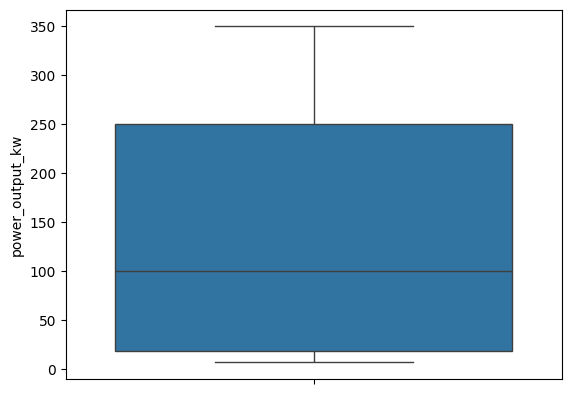

In [382]:
sns.boxplot(data['power_output_kw'])

<Axes: ylabel='ports_total'>

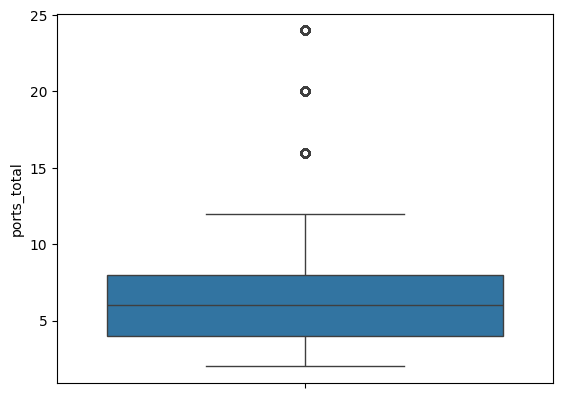

In [383]:
sns.boxplot(data['ports_total'])

<Axes: ylabel='ports_available'>

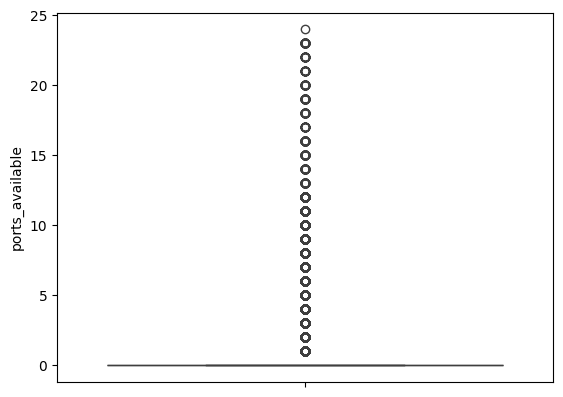

In [384]:
sns.boxplot(data['ports_available'])

<Axes: ylabel='ports_occupied'>

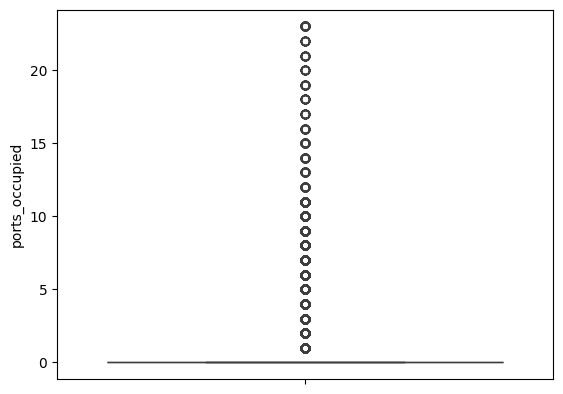

In [385]:
sns.boxplot(data['ports_occupied'])

<Axes: ylabel='ports_out_of_service'>

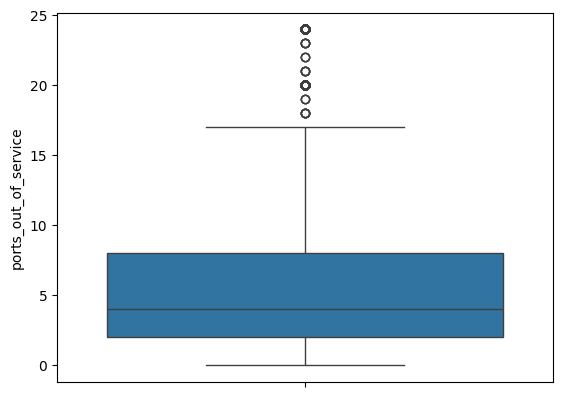

In [386]:
sns.boxplot(data['ports_out_of_service'])

<Axes: ylabel='utilization_rate'>

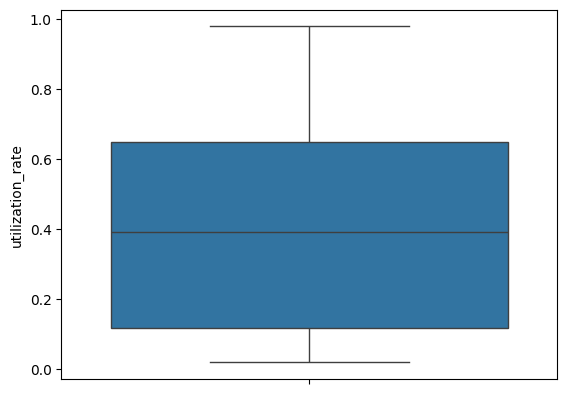

In [387]:
sns.boxplot(data['utilization_rate'])

<Axes: ylabel='estimated_wait_time_mins'>

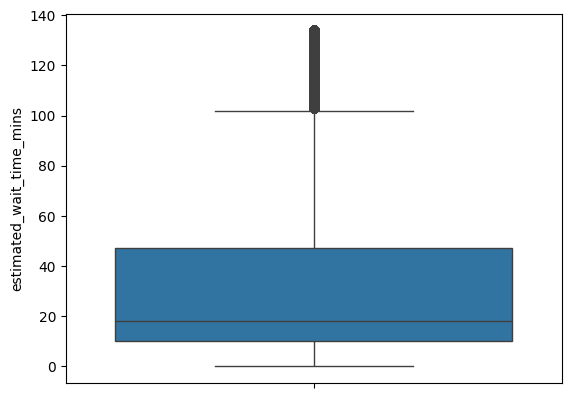

In [388]:
sns.boxplot(data['estimated_wait_time_mins'])

<Axes: ylabel='avg_session_duration_mins'>

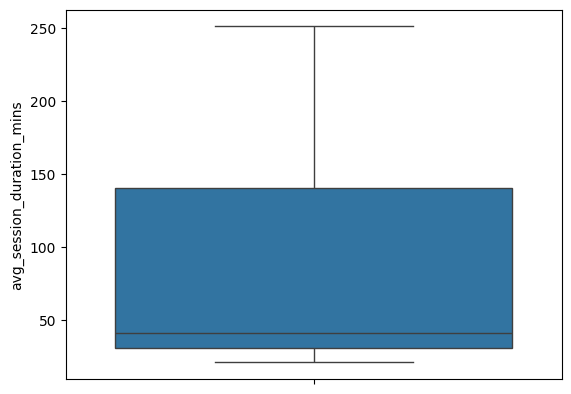

In [389]:
sns.boxplot(data['avg_session_duration_mins'])

<Axes: ylabel='current_price'>

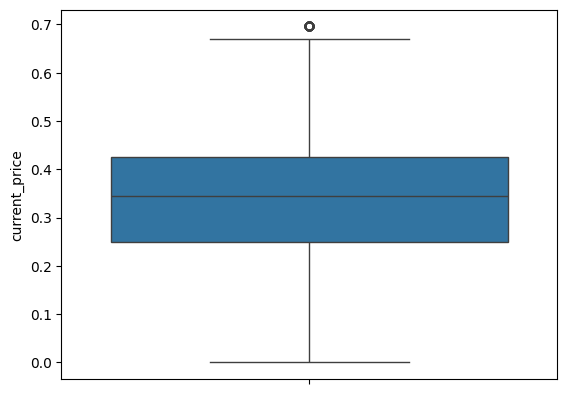

In [390]:
sns.boxplot(data['current_price'])

<Axes: ylabel='temperature_f'>

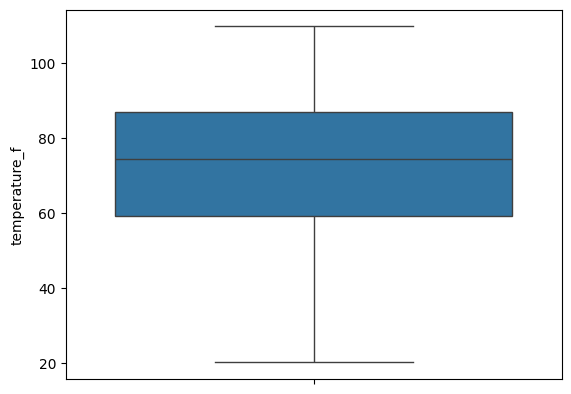

In [391]:
sns.boxplot(data['temperature_f'])

<Axes: ylabel='precipitation_mm'>

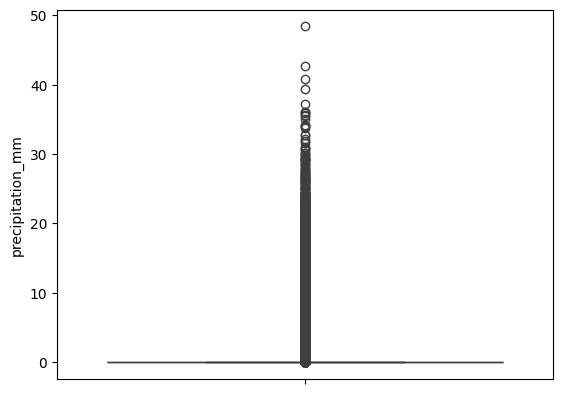

In [392]:
sns.boxplot(data['precipitation_mm'])

<Axes: ylabel='gas_price_per_gallon'>

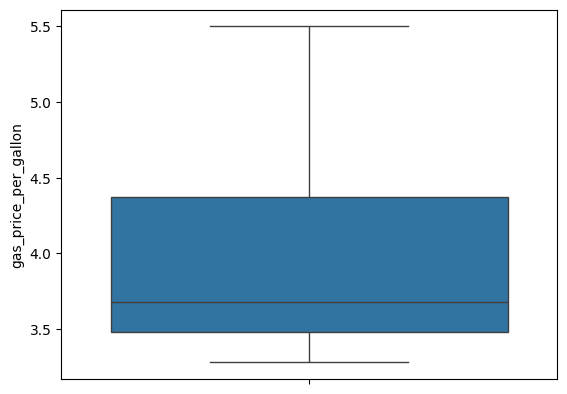

In [393]:
sns.boxplot(data['gas_price_per_gallon'])

<Axes: ylabel='traffic_congestion_index'>

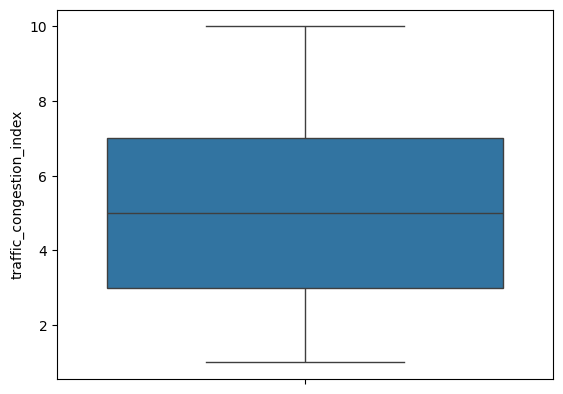

In [394]:
sns.boxplot(data['traffic_congestion_index'])

<Axes: ylabel='hour_of_day'>

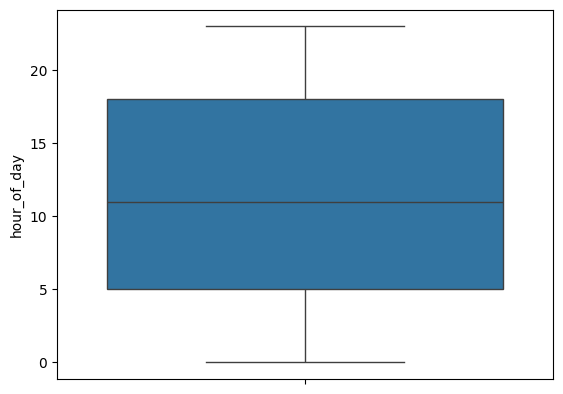

In [395]:
sns.boxplot(data['hour_of_day'])

<Axes: ylabel='day_of_week'>

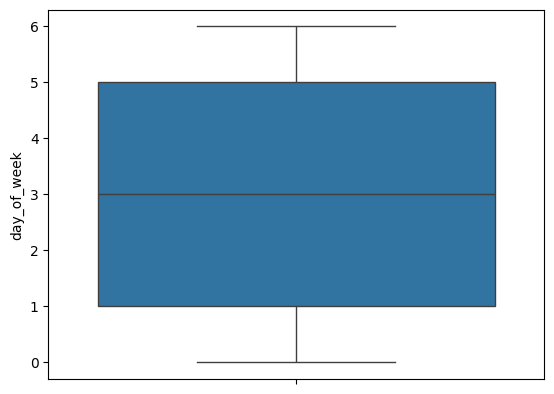

In [396]:
sns.boxplot(data['day_of_week'])

<Axes: ylabel='month'>

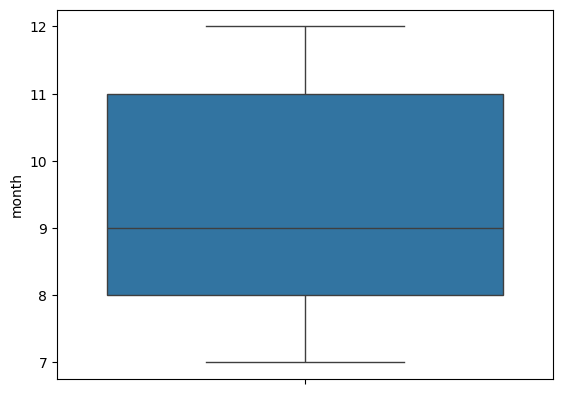

In [397]:
sns.boxplot(data['month'])

<Axes: ylabel='day_of_week'>

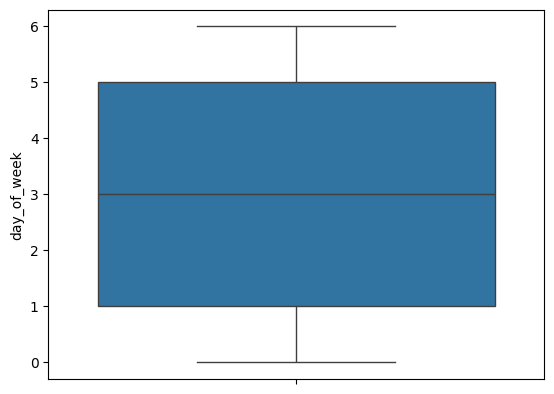

In [398]:
sns.boxplot(data['day_of_week'])

<Axes: ylabel='month'>

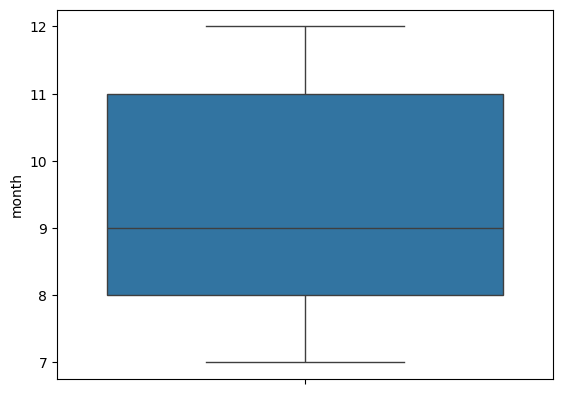

In [399]:
sns.boxplot(data['month'])

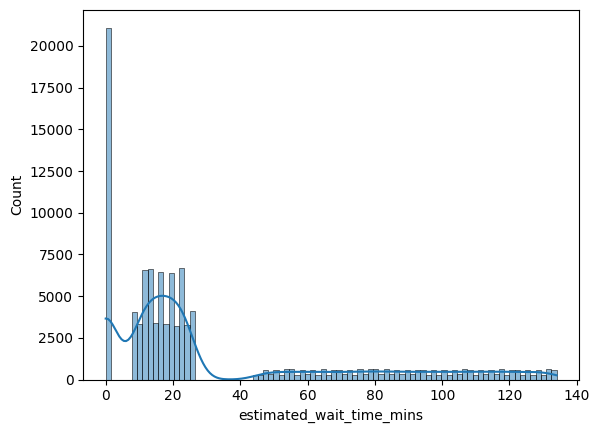

In [400]:
import matplotlib.pyplot as plt
sns.histplot(data['estimated_wait_time_mins'], kde=True)
plt.show()

In [401]:
data.dtypes

,0
power_output_kw,float64
ports_total,int64
ports_available,int64
ports_occupied,int64
ports_out_of_service,int64
...,...
local_event_concert,int64
local_event_conference,int64
local_event_festival,int64
local_event_none,int64


In [402]:
data.select_dtypes(include='object').columns

Index([], dtype='object')

## Train Test Split Data

In [403]:
X = data.drop('estimated_wait_time_mins', axis=1)

y = data['estimated_wait_time_mins']

In [404]:
print(X.shape)
print(y.shape)

(105477, 86)
(105477,)


In [405]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(84381, 86)
(21096, 86)
(84381,)
(21096,)


### Training Regression Models

In [406]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

print(f"Training R-squared score: {linear_model.score(X_train, y_train):}")
print(f"Testing R-squared score: {linear_model.score(X_test, y_test):}")


Training R-squared score: 0.7167186084922799
Testing R-squared score: 0.7148844013065612


# DecisionTree

In [407]:
#DecisionTree
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

print(f"Training R-squared score: {tree_model.score(X_train, y_train):}")
print(f"Testing R-squared score: {tree_model.score(X_test, y_test):}")

Training R-squared score: 1.0
Testing R-squared score: 0.7241129489695728


In [ ]:
y_train_pred_tree = tree_model.predict(X_train)
y_test_pred_tree = tree_model.predict(X_test)

print("Decision Tree Regressor Evaluation:")
print(f"  Train MSE: {mean_squared_error(y_train, y_train_pred_tree):.2f}")
print(f"  Test MSE: {mean_squared_error(y_test, y_test_pred_tree):.2f}")
print(f"  Train MAE: {mean_absolute_error(y_train, y_train_pred_tree):.2f}")
print(f"  Test MAE: {mean_absolute_error(y_test, y_test_pred_tree):.2f}")

### RandomForest Regressor

In [ ]:
# RandomForest Regressor
from sklearn.ensemble import RandomForestRegressor

rfr_model = RandomForestRegressor(random_state=42)
rfr_model.fit(X_train, y_train)

print(f"Random Forest Regressor Training R-squared score: {rfr_model.score(X_train, y_train):.2f}")
print(f"Random Forest Regressor Testing R-squared score: {rfr_model.score(X_test, y_test):.2f}")

In [408]:
# RandomForest Regressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_train_pred_rfr = rfr_model.predict(X_train)
y_test_pred_rfr = rfr_model.predict(X_test)

print("Random Forest Regressor Evaluation:")
print(f"  Train MSE: {mean_squared_error(y_train, y_train_pred_rfr):.2f}")
print(f"  Test MSE: {mean_squared_error(y_test, y_test_pred_rfr):.2f}")
print(f"  Train MAE: {mean_absolute_error(y_train, y_train_pred_rfr):.2f}")
print(f"  Test MAE: {mean_absolute_error(y_test, y_test_pred_rfr):.2f}")

Random Forest Regressor Evaluation:
  Train MSE: 26.67
  Test MSE: 190.71
  Train MAE: 3.04
  Test MAE: 8.16


# GadientBoostingRegressor

In [409]:
#GradientBoostingRegressor
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = GradientBoostingRegressor(random_state=42)
gbr_model.fit(X_train, y_train)

print(f"Gradient Boosting Regressor Training R-squared score: {gbr_model.score(X_train, y_train):.2f}")
print(f"Gradient Boosting Regressor Testing R-squared score: {gbr_model.score(X_test, y_test):.2f}")

Gradient Boosting Regressor Training R-squared score: 0.86
Gradient Boosting Regressor Testing R-squared score: 0.86


In [410]:
y_train_pred_gbr = gbr_model.predict(X_train)
y_test_pred_gbr = gbr_model.predict(X_test)

print("Gradient Boosting Regressor Evaluation:")
print(f"  Train MSE: {mean_squared_error(y_train, y_train_pred_gbr):.2f}")
print(f"  Test MSE: {mean_squared_error(y_test, y_test_pred_gbr):.2f}")
print(f"  Train MAE: {mean_absolute_error(y_train, y_train_pred_gbr):.2f}")
print(f"  Test MAE: {mean_absolute_error(y_test, y_test_pred_gbr):.2f}")

Gradient Boosting Regressor Evaluation:
  Train MSE: 184.20
  Test MSE: 184.89
  Train MAE: 8.13
  Test MAE: 8.11


### Make Predictions with Gradient Boosting Regressor

In [411]:
y_pred_gbr = gbr_model.predict(X_test)

print("Sample of Gradient Boosting Regressor Predictions on Test Set:")
for i in range(5):
    print(f"Actual: {y_test.iloc[i]:.2f}, Predicted: {y_pred_gbr[i]:.2f}")

Sample of Gradient Boosting Regressor Predictions on Test Set:
Actual: 14.00, Predicted: 17.08
Actual: 0.00, Predicted: 0.01
Actual: 18.00, Predicted: 16.96
Actual: 15.00, Predicted: 17.09
Actual: 24.00, Predicted: 17.03


In [412]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gbr_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

                      Feature  Importance
65       charger_type_Level 2    0.461509
2             ports_available    0.389670
6   avg_session_duration_mins    0.147889
8               temperature_f    0.000187
10       gas_price_per_gallon    0.000156
5            utilization_rate    0.000087
7               current_price    0.000062
14                hour_of_day    0.000056
4        ports_out_of_service    0.000055
9            precipitation_mm    0.000047


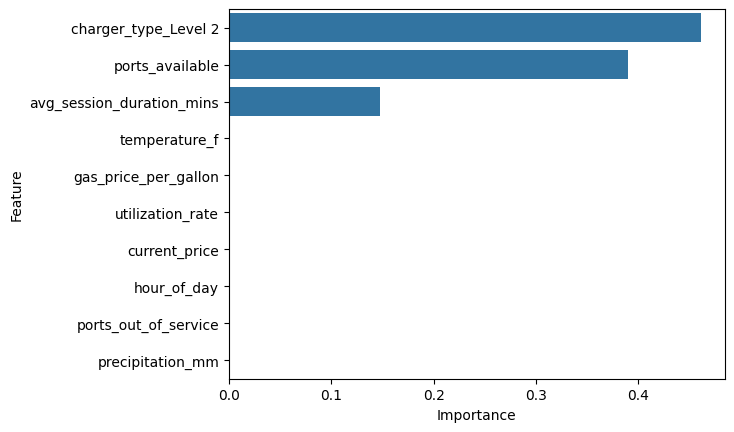

In [413]:
sns.barplot( x='Importance', y='Feature', data=feature_importance.head(10))

plt.show()


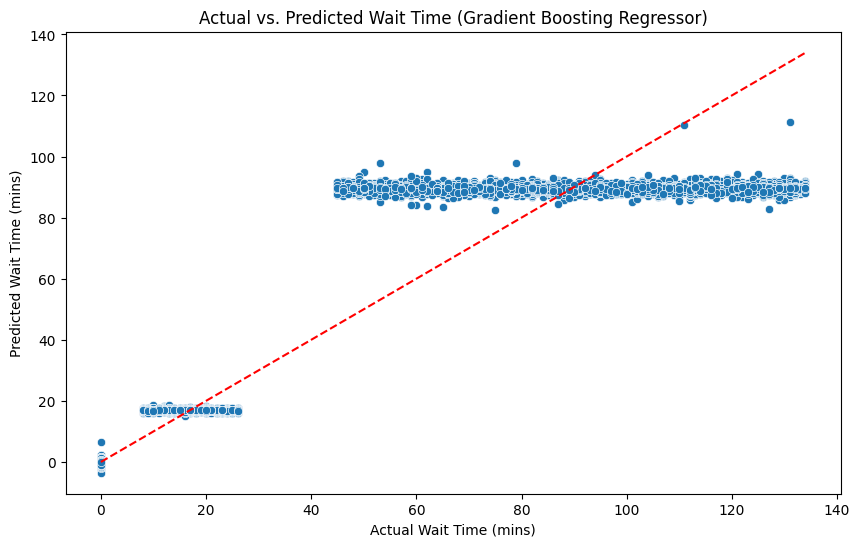

In [414]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_gbr)
plt.xlabel("Actual Wait Time (mins)")
plt.ylabel("Predicted Wait Time (mins)")
plt.title("Actual vs. Predicted Wait Time (Gradient Boosting Regressor)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Perfect prediction line
plt.show()

In [415]:
print(data['estimated_wait_time_mins'].describe())
print(data['estimated_wait_time_mins'].value_counts().head(20))


count    105477.000000
mean         32.152422
std          36.871200
min           0.000000
25%          10.000000
50%          18.000000
75%          47.000000
max         134.000000
Name: estimated_wait_time_mins, dtype: float64
estimated_wait_time_mins
0     21095
15     3365
14     3345
22     3336
25     3335
18     3333
23     3327
10     3303
13     3294
12     3294
16     3274
11     3263
9      3254
24     3245
21     3227
20     3209
19     3207
17     3193
8       810
26      779
Name: count, dtype: int64


In [416]:
print(pd.Series(y_pred_gbr).describe())

count    21096.000000
mean        32.085581
std         34.188310
min         -3.523444
25%         16.839015
50%         17.016554
75%         87.504481
max        111.178171
dtype: float64


In [417]:
data.groupby('ports_available')['estimated_wait_time_mins'].mean()

,estimated_wait_time_mins
ports_available,
0,40.190337
1,0.000000
2,0.000000
3,0.000000
4,0.000000
5,0.000000
6,0.000000
7,0.000000
8,0.000000


In [418]:
data[['ports_available','estimated_wait_time_mins']].corr()

,ports_available,estimated_wait_time_mins
ports_available,1.000000,-0.335073
estimated_wait_time_mins,-0.335073,1.000000


In [419]:
corr = data.corr(numeric_only=True)

print(
    corr['estimated_wait_time_mins']
    .sort_values(ascending=False)
    .head(15)
)

estimated_wait_time_mins            1.000000
charger_type_Level 2                0.726506
avg_session_duration_mins           0.682945
network_Volta                       0.410800
pricing_type_free                   0.410800
ports_out_of_service                0.247794
station_status_offline              0.222749
location_type_Shopping Center       0.162294
network_Blink                       0.147705
station_status_under_maintenance    0.134290
network_ChargePoint                 0.111956
city_San Diego                      0.103413
state_CO                            0.085807
city_Denver                         0.085807
state_CA                            0.072103
Name: estimated_wait_time_mins, dtype: float64


In [420]:
print(
    corr['estimated_wait_time_mins']
    .sort_values()
    .head(15)
)

charger_type_DC Fast Charge   -0.476445
station_status_operational    -0.420106
power_output_kw               -0.399917
ports_available               -0.335073
current_price                 -0.332483
pricing_type_per_kwh          -0.282419
ports_occupied                -0.245921
network_Electrify America     -0.220144
network_Shell Recharge        -0.205302
charger_type_Tesla DC Fast    -0.192425
network_Tesla Supercharger    -0.192425
charger_type_Hyper-Fast       -0.144033
pricing_type_per_minute       -0.123982
network_EVgo                  -0.123982
city_Atlanta                  -0.102220
Name: estimated_wait_time_mins, dtype: float64


In [421]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gbr_model.feature_importances_
})

print(feature_importance.sort_values(
    by='Importance',
    ascending=False
).head(15))

                             Feature  Importance
65              charger_type_Level 2    0.461509
2                    ports_available    0.389670
6          avg_session_duration_mins    0.147889
8                      temperature_f    0.000187
10              gas_price_per_gallon    0.000156
5                   utilization_rate    0.000087
7                      current_price    0.000062
14                       hour_of_day    0.000056
4               ports_out_of_service    0.000055
9                   precipitation_mm    0.000047
17           station_id_freq_encoded    0.000041
70  station_status_under_maintenance    0.000040
15                       day_of_week    0.000038
0                    power_output_kw    0.000026
18     amenities_nearby_freq_encoded    0.000023


In [422]:
print((data['estimated_wait_time_mins'] > 0).sum())

84382


In [423]:
from xgboost import XGBRegressor

In [424]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Results")
print("R2 :", r2_score(y_test, y_pred_xgb))
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("MSE:", mean_squared_error(y_test, y_pred_xgb))

XGBoost Results
R2 : 0.8625496029853821
MAE: 8.15827751159668
MSE: 185.93252563476562


In [425]:
print("Distribution of 'estimated_wait_time_mins':")
print(data['estimated_wait_time_mins'].value_counts().head(20))

Distribution of 'estimated_wait_time_mins':
estimated_wait_time_mins
0     21095
15     3365
14     3345
22     3336
25     3335
18     3333
23     3327
10     3303
13     3294
12     3294
16     3274
11     3263
9      3254
24     3245
21     3227
20     3209
19     3207
17     3193
8       810
26      779
Name: count, dtype: int64


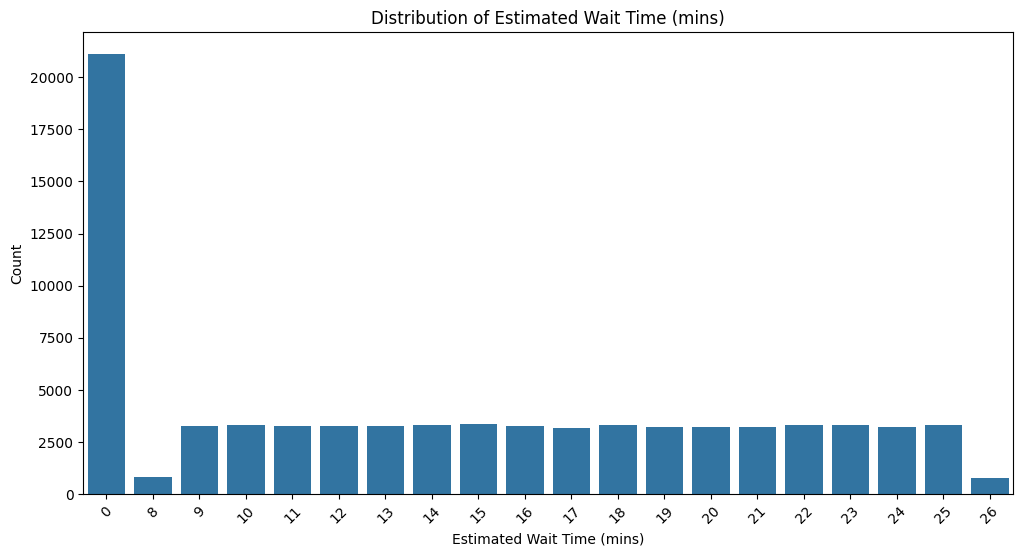

In [427]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
# Get the value counts and plot the top 20 to emphasize the imbalance
sns.barplot(x=data['estimated_wait_time_mins'].value_counts().head(20).index, y=data['estimated_wait_time_mins'].value_counts().head(20).values)
plt.title('Distribution of Estimated Wait Time (mins)')
plt.xlabel('Estimated Wait Time (mins)')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

## Two-Part Model Approach: Handling Zero-Inflated Data

Given the high proportion of zero values in `estimated_wait_time_mins`, a two-part modeling approach is more suitable. This involves:

1.  **Classification Model:** Predicting whether there will be a wait time (binary: 0 or >0).
2.  **Regression Model:** Predicting the actual wait time for instances where a wait time is predicted to occur (i.e., `estimated_wait_time_mins > 0`).

In [442]:
# Create a binary target variable 'is_wait' (1 if wait_time > 0, 0 otherwise)
data['is_wait'] = (data['estimated_wait_time_mins'] > 0).astype(int)

print(data['is_wait'].value_counts())

is_wait
1    84382
0    21095
Name: count, dtype: int64


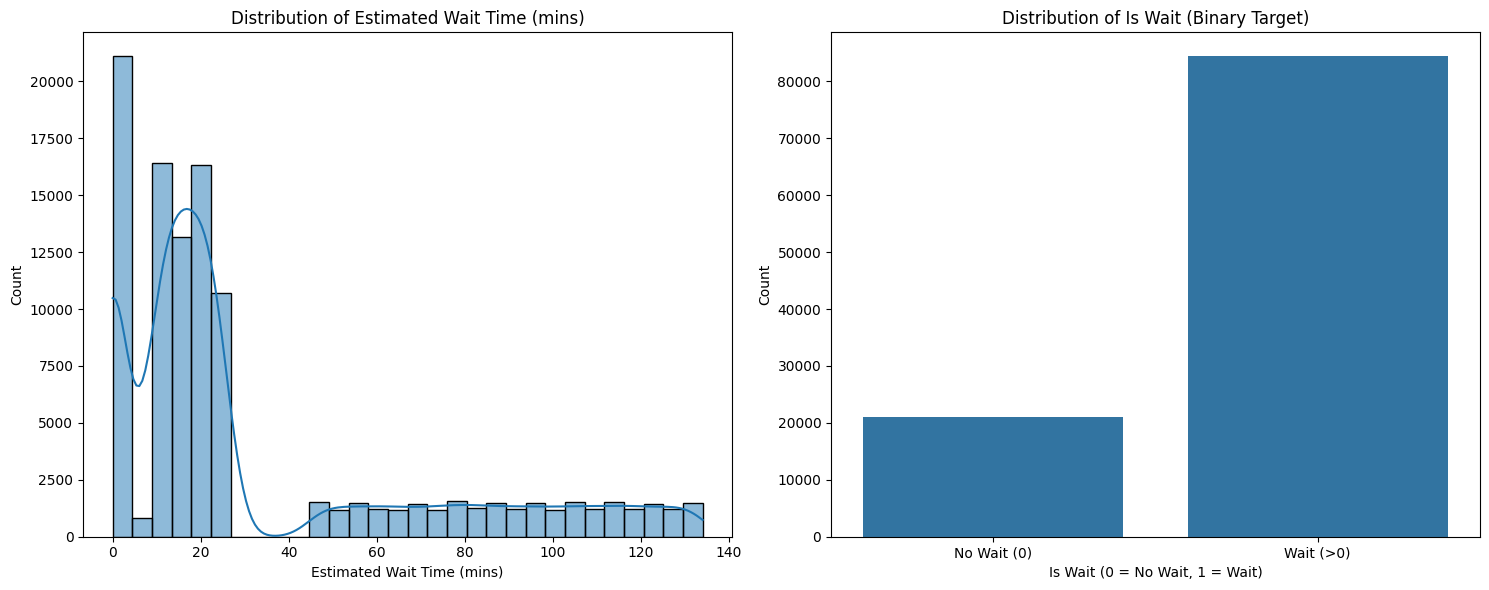

In [443]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))

# Plot 1: Distribution of Estimated Wait Time (mins)
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(data['estimated_wait_time_mins'], kde=True, bins=30)
plt.title('Distribution of Estimated Wait Time (mins)')
plt.xlabel('Estimated Wait Time (mins)')
plt.ylabel('Count')

# Plot 2: Distribution of 'is_wait' binary target
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.countplot(x=data['is_wait'])
plt.title('Distribution of Is Wait (Binary Target)')
plt.xlabel('Is Wait (0 = No Wait, 1 = Wait)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['No Wait (0)', 'Wait (>0)'])

plt.tight_layout()
plt.show()

First, let's prepare the datasets for our two-part model: one for classification (predicting if there's a wait) and one for regression (predicting the wait time when there is one).

In [444]:
# Features for both models (excluding 'estimated_wait_time_mins' and 'is_wait')
X_common = data.drop(['estimated_wait_time_mins', 'is_wait'], axis=1)

# Target for classification (is_wait)
y_classification = data['is_wait']

# Filter data for regression: only consider instances where estimated_wait_time_mins > 0
data_for_regression = data[data['estimated_wait_time_mins'] > 0]
X_regression = data_for_regression.drop(['estimated_wait_time_mins', 'is_wait'], axis=1)
y_regression = data_for_regression['estimated_wait_time_mins']

print(f"X_common shape: {X_common.shape}")
print(f"y_classification shape: {y_classification.shape}")
print(f"X_regression shape (where wait > 0): {X_regression.shape}")
print(f"y_regression shape (where wait > 0): {y_regression.shape}")

X_common shape: (105477, 86)
y_classification shape: (105477,)
X_regression shape (where wait > 0): (84382, 86)
y_regression shape (where wait > 0): (84382,)


Now, let's split both the classification and regression datasets into training and testing sets.

In [445]:
from sklearn.model_selection import train_test_split

# Split data for classification model
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_common,
    y_classification,
    test_size=0.2,
    random_state=42,
    stratify=y_classification # Stratify to maintain the proportion of 0s and 1s
)

# Split data for regression model (only non-zero wait times)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_regression,
    y_regression,
    test_size=0.2,
    random_state=42
)

print("Classification Data Splits:")
print(f"  X_train_clf shape: {X_train_clf.shape}")
print(f"  X_test_clf shape: {X_test_clf.shape}")
print(f"  y_train_clf shape: {y_train_clf.shape}")
print(f"  y_test_clf shape: {y_test_clf.shape}")

print("\nRegression Data Splits:")
print(f"  X_train_reg shape: {X_train_reg.shape}")
print(f"  X_test_reg shape: {X_test_reg.shape}")
print(f"  y_train_reg shape: {y_train_reg.shape}")
print(f"  y_test_reg shape: {y_test_reg.shape}")

Classification Data Splits:
  X_train_clf shape: (84381, 86)
  X_test_clf shape: (21096, 86)
  y_train_clf shape: (84381,)
  y_test_clf shape: (21096,)

Regression Data Splits:
  X_train_reg shape: (67505, 86)
  X_test_reg shape: (16877, 86)
  y_train_reg shape: (67505,)
  y_test_reg shape: (16877,)


### Part 1: Classification Model (Predicting if there is a wait or not)

We'll use a Logistic Regression model to predict the binary outcome (`is_wait`).

In [459]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Initialize and train the Logistic Regression model for classification
clf_model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced') # 'balanced' to handle potential class imbalance
clf_model.fit(X_train_clf, y_train_clf)

# Make predictions on the test set
y_pred_clf = clf_model.predict(X_test_clf)
y_prob_clf = clf_model.predict_proba(X_test_clf)[:, 1] # Probabilities for the positive class

# Evaluate the classification model
print("Logistic Regression Classification Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test_clf, y_pred_clf):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test_clf, y_prob_clf):.4f}")

Logistic Regression Classification Model Evaluation:
Accuracy: 1.0000
ROC AUC Score: 1.0000


### Trying Other Classification Models

#### Random Forest Classifier

In [456]:
from sklearn.ensemble import RandomForestClassifier

rfc_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rfc_model.fit(X_train_clf, y_train_clf)

y_pred_rfc = rfc_model.predict(X_test_clf)
y_prob_rfc = rfc_model.predict_proba(X_test_clf)[:, 1]

print("Random Forest Classifier Evaluation:")
print(f"Accuracy: {accuracy_score(y_test_clf, y_pred_rfc):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test_clf, y_prob_rfc):.4f}")

Random Forest Classifier Evaluation:
Accuracy: 1.0000
ROC AUC Score: 1.0000


#### Decision Tree Classifier

In [457]:
from sklearn.tree import DecisionTreeClassifier

dtc_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dtc_model.fit(X_train_clf, y_train_clf)

y_pred_dtc = dtc_model.predict(X_test_clf)
y_prob_dtc = dtc_model.predict_proba(X_test_clf)[:, 1]

print("Decision Tree Classifier Evaluation:")
print(f"Accuracy: {accuracy_score(y_test_clf, y_pred_dtc):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test_clf, y_prob_dtc):.4f}")

Decision Tree Classifier Evaluation:
Accuracy: 1.0000
ROC AUC Score: 1.0000


#### XGBoost Classifier

In [458]:
from xgboost import XGBClassifier

xgb_clf_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    use_label_encoder=False, # Suppress warning
    eval_metric='logloss'    # Suppress warning
)
xgb_clf_model.fit(X_train_clf, y_train_clf)

y_pred_xgb_clf = xgb_clf_model.predict(X_test_clf)
y_prob_xgb_clf = xgb_clf_model.predict_proba(X_test_clf)[:, 1]

print("XGBoost Classifier Evaluation:")
print(f"Accuracy: {accuracy_score(y_test_clf, y_pred_xgb_clf):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test_clf, y_prob_xgb_clf):.4f}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:13:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classifier Evaluation:
Accuracy: 1.0000
ROC AUC Score: 1.0000


## Part 2: Regression Model (Predicting actual wait time for non-zero cases)

Now, we'll use the *already trained Gradient Boosting Regressor (`gbr_model`)* to predict the actual `estimated_wait_time_mins` for cases where `is_wait` is 1. We will evaluate its performance specifically on the subset of the test data where wait times are non-zero.

### Gradient Boosting Regression Model

In [460]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Use the already trained gbr_model to make predictions on the regression test set
y_pred_reg_reused = gbr_model.predict(X_test_reg)

# Also make predictions on the regression training set for evaluation
y_pred_train_reg_reused = gbr_model.predict(X_train_reg)

# Evaluate the gbr_model on the subset of data with non-zero wait times
print("Gradient Boosting Regression Model Evaluation (for non-zero wait times, reusing gbr_model):")
print(f"  Training R-squared: {r2_score(y_train_reg, y_pred_train_reg_reused):.4f}")
print(f"  Testing R-squared: {r2_score(y_test_reg, y_pred_reg_reused):.4f}")
print(f"  Mean Squared Error (MSE): {mean_squared_error(y_test_reg, y_pred_reg_reused):.2f}")
print(f"  Mean Absolute Error (MAE): {mean_absolute_error(y_test_reg, y_pred_reg_reused):.2f}")

Gradient Boosting Regression Model Evaluation (for non-zero wait times, reusing gbr_model):
  Training R-squared: 0.8331
  Testing R-squared: 0.8306
  Mean Squared Error (MSE): 227.74
  Mean Absolute Error (MAE): 10.06


### Training a New XGBoost Regressor (for non-zero wait times)

In [461]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Initialize and train a new XGBoost Regressor model for regression component
xgb_reg_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='rmse' # A common metric for regression
)
xgb_reg_model.fit(X_train_reg, y_train_reg)

# Make predictions on the regression test set
y_pred_xgb_reg = xgb_reg_model.predict(X_test_reg)

# Make predictions on the regression training set
y_pred_train_xgb_reg = xgb_reg_model.predict(X_train_reg)

# Evaluate the new XGBoost Regressor model on the subset of data with non-zero wait times
print("XGBoost Regressor Evaluation (trained on non-zero wait times):")
print(f"  Training R-squared: {r2_score(y_train_reg, y_pred_train_xgb_reg):.4f}")
print(f"  Testing R-squared: {r2_score(y_test_reg, y_pred_xgb_reg):.4f}")
print(f"  Mean Squared Error (MSE): {mean_squared_error(y_test_reg, y_pred_xgb_reg):.2f}")
print(f"  Mean Absolute Error (MAE): {mean_absolute_error(y_test_reg, y_pred_xgb_reg):.2f}")

XGBoost Regressor Evaluation (trained on non-zero wait times):
  Training R-squared: 0.8527
  Testing R-squared: 0.8270
  Mean Squared Error (MSE): 232.51
  Mean Absolute Error (MAE): 10.14


### Training a New Random Forest Regressor (for non-zero wait times)

In [463]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Initialize and train a new Random Forest Regressor model for regression component
rfr_reg_model = RandomForestRegressor(random_state=42)
rfr_reg_model.fit(X_train_reg, y_train_reg)

# Make predictions on the regression test set
y_pred_rfr_reg = rfr_reg_model.predict(X_test_reg)

# Make predictions on the regression training set
y_pred_train_rfr_reg = rfr_reg_model.predict(X_train_reg)

# Evaluate the new RFR model on the subset of data with non-zero wait times
print("Random Forest Regressor Evaluation (trained on non-zero wait times):")
print(f"  Training R-squared: {r2_score(y_train_reg, y_pred_train_rfr_reg):.4f}")
print(f"  Testing R-squared: {r2_score(y_test_reg, y_pred_rfr_reg):.4f}")
print(f"  Mean Squared Error (MSE): {mean_squared_error(y_test_reg, y_pred_rfr_reg):.2f}")
print(f"  Mean Absolute Error (MAE): {mean_absolute_error(y_test_reg, y_pred_rfr_reg):.2f}")

Random Forest Regressor Evaluation (trained on non-zero wait times):
  Training R-squared: 0.9756
  Testing R-squared: 0.8244
  Mean Squared Error (MSE): 236.02
  Mean Absolute Error (MAE): 10.19


### Summary of Regression Model Performance (Predicting Non-Zero Wait Times)

In [464]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n--- Regression Model Performance Summary (on non-zero wait times) ---")

# GBR Model (reused)
print("\nGradient Boosting Regressor (reused from full dataset training):")
print(f"  Training R-squared: {r2_score(y_train_reg, y_pred_train_reg_reused):.4f}")
print(f"  Testing R-squared: {r2_score(y_test_reg, y_pred_reg_reused):.4f}")
print(f"  Mean Squared Error (MSE): {mean_squared_error(y_test_reg, y_pred_reg_reused):.2f}")
print(f"  Mean Absolute Error (MAE): {mean_absolute_error(y_test_reg, y_pred_reg_reused):.2f}")

# XGBoost Regressor (newly trained)
print("\nXGBoost Regressor (newly trained on non-zero data):")
print(f"  Training R-squared: {r2_score(y_train_reg, y_pred_train_xgb_reg):.4f}")
print(f"  Testing R-squared: {r2_score(y_test_reg, y_pred_xgb_reg):.4f}")
print(f"  Mean Squared Error (MSE): {mean_squared_error(y_test_reg, y_pred_xgb_reg):.2f}")
print(f"  Mean Absolute Error (MAE): {mean_absolute_error(y_test_reg, y_pred_xgb_reg):.2f}")

# Random Forest Regressor (newly trained)
print("\nRandom Forest Regressor (newly trained on non-zero data):")
print(f"  Training R-squared: {r2_score(y_train_reg, y_pred_train_rfr_reg):.4f}")
print(f"  Testing R-squared: {r2_score(y_test_reg, y_pred_rfr_reg):.4f}")
print(f"  Mean Squared Error (MSE): {mean_squared_error(y_test_reg, y_pred_rfr_reg):.2f}")
print(f"  Mean Absolute Error (MAE): {mean_absolute_error(y_test_reg, y_pred_rfr_reg):.2f}")


--- Regression Model Performance Summary (on non-zero wait times) ---

Gradient Boosting Regressor (reused from full dataset training):
  Training R-squared: 0.8331
  Testing R-squared: 0.8306
  Mean Squared Error (MSE): 227.74
  Mean Absolute Error (MAE): 10.06

XGBoost Regressor (newly trained on non-zero data):
  Training R-squared: 0.8527
  Testing R-squared: 0.8270
  Mean Squared Error (MSE): 232.51
  Mean Absolute Error (MAE): 10.14

Random Forest Regressor (newly trained on non-zero data):
  Training R-squared: 0.9756
  Testing R-squared: 0.8244
  Mean Squared Error (MSE): 236.02
  Mean Absolute Error (MAE): 10.19


####The Gradient Boosting Regressor is best performing

## Combining the Two Models for a Unified Prediction

Now, let's create a function that uses both models to make a final prediction for `estimated_wait_time_mins`.

In [448]:
def predict_wait_time(features):
    # Ensure features are in the correct format (DataFrame)
    if isinstance(features, pd.Series):
        features = features.to_frame().T
    elif isinstance(features, np.ndarray):
        features = pd.DataFrame(features, columns=X_common.columns) # Assuming X_common columns are used

    # Step 1: Predict if there will be a wait (classification)
    is_wait_prediction = clf_model.predict(features)

    if is_wait_prediction[0] == 1: # If the classification model predicts a wait
        # Step 2: Predict the actual wait time using the existing gbr_model
        # In this setup, X_common and X_train/X_test for gbr_model have the same columns.
        actual_wait_time_prediction = gbr_model.predict(features)
        # Ensure wait time is not negative (can happen with some regression models)
        return max(0, actual_wait_time_prediction[0])
    else: # If the classification model predicts no wait
        return 0.0

print("Combined prediction function defined.")

Combined prediction function defined.


Let's test this combined prediction function on a few examples from the test set.

In [478]:
# Select a few samples from the test set for demonstration
sample_indices = X_test_clf.sample(10, random_state=42).index

print("Demonstrating combined model predictions:")
for idx in sample_indices:
    features_sample = X_test_clf.loc[idx]
    actual_wait_time = data.loc[idx, 'estimated_wait_time_mins']
    predicted_wait_time = predict_wait_time(features_sample)

    print(f"  Sample Index: {idx}")
    print(f"    Actual Wait Time: {actual_wait_time:.2f} mins")
    print(f"    Predicted Wait Time: {predicted_wait_time:.2f} mins")
    print("-" * 30)

Demonstrating combined model predictions:
  Sample Index: 20537
    Actual Wait Time: 103.00 mins
    Predicted Wait Time: 88.71 mins
------------------------------
  Sample Index: 33147
    Actual Wait Time: 95.00 mins
    Predicted Wait Time: 90.28 mins
------------------------------
  Sample Index: 11880
    Actual Wait Time: 14.00 mins
    Predicted Wait Time: 17.06 mins
------------------------------
  Sample Index: 45569
    Actual Wait Time: 19.00 mins
    Predicted Wait Time: 17.14 mins
------------------------------
  Sample Index: 7970
    Actual Wait Time: 16.00 mins
    Predicted Wait Time: 17.11 mins
------------------------------
  Sample Index: 22852
    Actual Wait Time: 14.00 mins
    Predicted Wait Time: 16.86 mins
------------------------------
  Sample Index: 62256
    Actual Wait Time: 111.00 mins
    Predicted Wait Time: 89.37 mins
------------------------------
  Sample Index: 78365
    Actual Wait Time: 10.00 mins
    Predicted Wait Time: 16.76 mins
------------

## Overall Evaluation of the Two-Part Model

To evaluate the overall performance of the two-part model, we need to apply the combined prediction logic to the entire test set (`X_test_clf`) and compare the results against the true `estimated_wait_time_mins`.

In [450]:
y_pred_combined = []
for idx in X_test_clf.index:
    features_to_predict = X_test_clf.loc[idx]
    y_pred_combined.append(predict_wait_time(features_to_predict))

y_pred_combined = np.array(y_pred_combined)

# Get the true values from the original data (estimated_wait_time_mins)
y_true_combined = data.loc[X_test_clf.index, 'estimated_wait_time_mins']

print("Overall Two-Part Model Evaluation:")
print(f"  R-squared: {r2_score(y_true_combined, y_pred_combined):.4f}")
print(f"  Mean Squared Error (MSE): {mean_squared_error(y_true_combined, y_pred_combined):.2f}")
print(f"  Mean Absolute Error (MAE): {mean_absolute_error(y_true_combined, y_pred_combined):.2f}")

Overall Two-Part Model Evaluation:
  R-squared: 0.8676
  Mean Squared Error (MSE): 180.93
  Mean Absolute Error (MAE): 8.01


Ini HPT cheytho